## Import Libraries & Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.sample(5)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
11271,1,Internet,RoundTrip,108,25,16,Thu,HANPER,Australia,1,0,0,5.62,0
26308,3,Internet,OneWay,5,2,4,Tue,PEKSBW,China,1,0,1,6.42,0
23114,1,Internet,RoundTrip,121,22,1,Mon,PERPNH,Australia,1,0,0,5.62,0
1253,1,Internet,RoundTrip,18,22,3,Mon,AKLKUL,Malaysia,0,0,0,8.83,0
46576,2,Internet,RoundTrip,20,6,7,Tue,HKTPUS,South Korea,0,0,1,6.33,0


## Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [4]:
# Duplication Check
print(f"Jumlah data duplikat: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

Jumlah data duplikat: 719


In [5]:
# Drop 'route' because has many unique values because can model overfitting
df = df.drop('route', axis=1)

In [6]:
# Recheck
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49281 entries, 0 to 49280
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         49281 non-null  int64  
 1   sales_channel          49281 non-null  object 
 2   trip_type              49281 non-null  object 
 3   purchase_lead          49281 non-null  int64  
 4   length_of_stay         49281 non-null  int64  
 5   flight_hour            49281 non-null  int64  
 6   flight_day             49281 non-null  object 
 7   booking_origin         49281 non-null  object 
 8   wants_extra_baggage    49281 non-null  int64  
 9   wants_preferred_seat   49281 non-null  int64  
 10  wants_in_flight_meals  49281 non-null  int64  
 11  flight_duration        49281 non-null  float64
 12  booking_complete       49281 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 4.9+ MB


In [7]:
# Mapping
flight_day_mapping = {"Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5, "Sat": 6, "Sun": 7}
df["flight_day"] = df["flight_day"].map(flight_day_mapping)
df.sample()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
30412,2,Internet,RoundTrip,93,4,9,2,Japan,0,0,1,7.0,0


## Data Splitting

In [8]:
X = pd.get_dummies(df.drop('booking_complete', axis=1))
y = df['booking_complete']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

In [9]:
# Random Forest
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

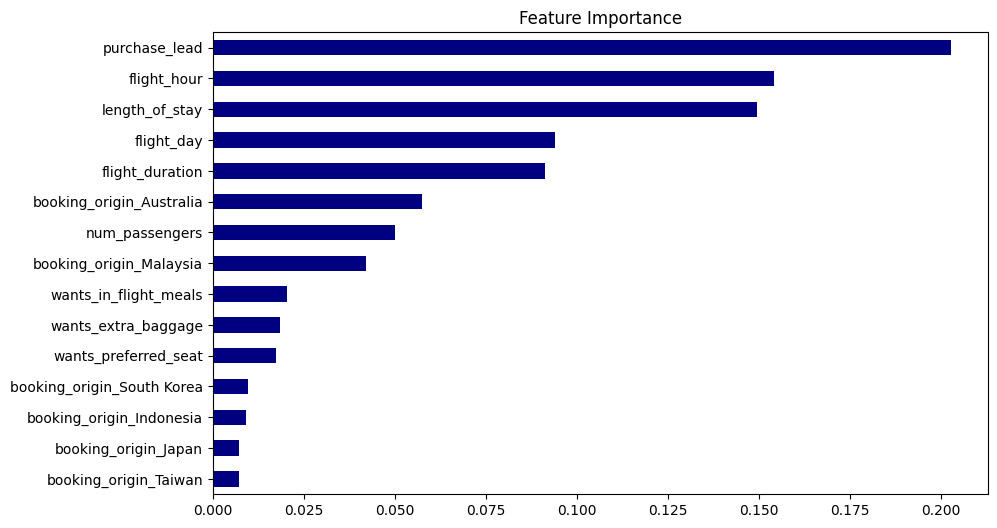

In [10]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances.nlargest(15).sort_values().plot(kind='barh', color='navy')
plt.title('Feature Importance')
plt.show()

In [11]:
# Classification Report
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8378
           1       0.48      0.08      0.14      1479

    accuracy                           0.85      9857
   macro avg       0.67      0.53      0.53      9857
weighted avg       0.80      0.85      0.80      9857

